# Improved Segmentation Pipeline — Beat No-Seg

**Goal:** Fix why the segmentation pipeline lost to raw-image classification.

**Root cause identified:**
- Hard-cropping throws away context (surrounding skin, wound borders) that is diagnostic for infection.
- Segmentation errors (~14% with old model) give the classifier bad inputs.

**Two fixes applied here:**
1. **Better segmentation model** — ImprovedUNet (base=48, ~15M params, dropout, 60 epochs)
2. **Mask overlay instead of hard crop** — wound stays full brightness, background dimmed to 50%. No information lost.

**Expected outcome:** With full context preserved + better mask quality, the classifier should beat NoSeg.

| Notebook | Saves to |
|---|---|
| This (10) | `segmentation_improved_unet.pth` + `cls_overlay_*.pth` |
| Compare against | `cls_noseg_*.pth` (notebook 08) |

**Prerequisite:** Raw `SegementationT+S+V/` dataset must exist (same as notebook 06_5).

## Cell 1: Imports & Configuration

In [2]:
import os, random, warnings, time, copy
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms.functional import adjust_brightness
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models
from sklearn.metrics import (accuracy_score, f1_score, roc_curve, auc,
                             precision_score, recall_score)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ── CPU optimization ──────────────────────────────────────────────────────
torch.set_num_threads(12)
torch.set_num_interop_threads(2)
torch.backends.mkldnn.enabled = True
DEVICE = torch.device('cpu')

# ── Paths ─────────────────────────────────────────────────────────────────
BASE          = r'C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry'
SEG_DATA      = os.path.join(BASE, 'SegementationT+S+V')
MODEL_DIR     = os.path.join(BASE, 'outputs', 'models')
VIZ_DIR       = os.path.join(BASE, 'outputs', 'visualizations')
RAW_CLS       = os.path.join(BASE, 'TRAINTEST')
OVERLAY_DIR   = os.path.join(BASE, 'outputs', 'overlay_data')
SEG_MODEL_PATH = os.path.join(MODEL_DIR, 'segmentation_improved_unet.pth')
OLD_SEG_PATH   = os.path.join(MODEL_DIR, 'segmentation_lightweight_unet.pth')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(VIZ_DIR,   exist_ok=True)

# ── Segmentation hyperparams ──────────────────────────────────────────────
IMG_SIZE     = 256
SEG_BATCH    = 8
SEG_EPOCHS   = 60
SEG_LR       = 8e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 12

# ── Classifier hyperparams (same as 07/08 for fair comparison) ────────────
CLS_SIZE     = 224
CLS_BATCH    = 32
P1_EP, P1_LR = 10, 5e-4
P2_EP, P2_LR = 15, 1e-4
P3_EP, P3_LR = 15, 1e-5
CLS_PATIENCE = 10
MIXUP_ALPHA  = 0.2

plt.rcParams.update({
    'figure.facecolor':'#0d1117', 'axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d',   'axes.labelcolor':'#c9d1d9',
    'text.color':'#c9d1d9',       'xtick.color':'#8b949e',
    'ytick.color':'#8b949e',      'grid.color':'#21262d', 'font.size':11
})
ACCENT, GREEN, BLUE, YELLOW, PURPLE = '#e94560','#3fb950','#58a6ff','#e3b341','#bc8cff'

print(f'Device      : {DEVICE}')
print(f'CPU threads : {torch.get_num_threads()}')
print(f'MKL-DNN     : {torch.backends.mkldnn.is_available()}')
print('Imports OK')

Device      : cpu
CPU threads : 12
MKL-DNN     : True
Imports OK


## Cell 2: Improved U-Net Model

**Changes vs LightUNet (06_5):**
- Base channels: 32 → 48 (params: ~7M → ~15M, still fast on CPU)
- Dropout(0.1) after each encoder block — reduces overfitting on small dataset
- Same 256×256 input, same output format (returns tensor directly, no dict)

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(p=dropout))
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class ImprovedUNet(nn.Module):
    """
    U-Net with base=48 channels and encoder dropout.
    ~15M params. Returns (B,1,H,W) logits directly — no dict wrapper.
    """
    def __init__(self, in_ch=3, out_ch=1, base=48, drop=0.10):
        super().__init__()
        b = base
        self.enc1       = ConvBlock(in_ch, b,    dropout=0)
        self.enc2       = ConvBlock(b,     b*2,  dropout=drop)
        self.enc3       = ConvBlock(b*2,   b*4,  dropout=drop)
        self.enc4       = ConvBlock(b*4,   b*8,  dropout=drop)
        self.bottleneck = ConvBlock(b*8,   b*16, dropout=drop)
        self.up4  = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4 = ConvBlock(b*16, b*8)
        self.up3  = nn.ConvTranspose2d(b*8,  b*4, 2, stride=2)
        self.dec3 = ConvBlock(b*8,  b*4)
        self.up2  = nn.ConvTranspose2d(b*4,  b*2, 2, stride=2)
        self.dec2 = ConvBlock(b*4,  b*2)
        self.up1  = nn.ConvTranspose2d(b*2,  b,   2, stride=2)
        self.dec1 = ConvBlock(b*2,  b)
        self.pool = nn.MaxPool2d(2)
        self.head = nn.Conv2d(b, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bn = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(bn), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)


model = ImprovedUNet(in_ch=3, out_ch=1, base=48, drop=0.10).to(DEVICE)
total_p = sum(p.numel() for p in model.parameters())
print(f'Model      : ImprovedUNet (base=48, dropout=0.10)')
print(f'Parameters : {total_p:,}  (~{total_p/1e6:.1f}M)')
print(f'Input      : (B, 3, {IMG_SIZE}, {IMG_SIZE})')
print(f'Output     : (B, 1, {IMG_SIZE}, {IMG_SIZE})  logits → sigmoid → mask')

with torch.inference_mode():
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    t0 = time.time()
    for _ in range(5): model(dummy)
    ms = (time.time()-t0)/5*1000
print(f'Forward pass: {ms:.0f} ms/image')

Model      : ImprovedUNet (base=48, dropout=0.10)
Parameters : 17,461,393  (~17.5M)
Input      : (B, 3, 256, 256)
Output     : (B, 1, 256, 256)  logits → sigmoid → mask
Forward pass: 154 ms/image


## Cell 3: Segmentation Dataset

In [4]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

class SegDataset(Dataset):
    def __init__(self, root, img_size=256, augment=False):
        self.img_dir  = os.path.join(root, 'images')
        self.lbl_dir  = os.path.join(root, 'labels')
        self.img_size = img_size
        self.augment  = augment
        self.files    = sorted([f for f in os.listdir(self.img_dir)
                                if os.path.splitext(f)[1].lower() in IMG_EXTS])
        self.img_tf   = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        print(f'  Caching {len(self.files)} masks from {os.path.basename(root)}...')
        self._mask_cache = {}
        for fname in self.files:
            with Image.open(os.path.join(self.img_dir, fname)) as im:
                W, H = im.size
            m = self._parse_mask(fname, W, H)
            m_rs = np.array(
                Image.fromarray((m*255).astype(np.uint8)).resize((img_size,img_size), Image.NEAREST)
            )
            self._mask_cache[fname] = m_rs
        print(f'  Done.')

    def _parse_mask(self, fname, W, H):
        stem = os.path.splitext(fname)[0]
        for ext in list(IMG_EXTS) + ['.txt']:
            c = os.path.join(self.lbl_dir, stem + ext)
            if not os.path.exists(c): continue
            if c.endswith('.txt'):
                mask = np.zeros((H,W), dtype=np.float32)
                with open(c) as f:
                    for line in f:
                        p = line.strip().split()
                        if len(p) < 5: continue
                        cx,cy,bw,bh = float(p[1]),float(p[2]),float(p[3]),float(p[4])
                        x1,x2 = int((cx-bw/2)*W), int((cx+bw/2)*W)
                        y1,y2 = int((cy-bh/2)*H), int((cy+bh/2)*H)
                        mask[max(0,y1):min(H,y2), max(0,x1):min(W,x2)] = 1.0
                return mask
            else:
                return np.array(Image.open(c).convert('L').resize((W,H),Image.NEAREST),dtype=np.float32)/255.0
        return np.zeros((H,W), dtype=np.float32)

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img   = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        mask  = self._mask_cache[fname].astype(np.float32) / 255.0

        if self.augment:
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_LEFT_RIGHT)
                mask = np.fliplr(mask).copy()
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_TOP_BOTTOM)
                mask = np.flipud(mask).copy()
            k = random.randint(0, 3)
            if k:
                img  = img.rotate(k*90)
                mask = np.rot90(mask, k=k).copy()
            if random.random() > 0.5:
                img = adjust_brightness(img, random.uniform(0.65, 1.35))
            # Extra: random perspective warp for shape variety
            if random.random() > 0.6:
                img = transforms.RandomPerspective(distortion_scale=0.2, p=1.0)(img)

        return self.img_tf(img), torch.from_numpy(mask).float().unsqueeze(0)


print('Building segmentation datasets...')
t0 = time.time()
train_seg = SegDataset(os.path.join(SEG_DATA,'train'),      IMG_SIZE, augment=True)
val_seg   = SegDataset(os.path.join(SEG_DATA,'validation'), IMG_SIZE, augment=False)
test_seg  = SegDataset(os.path.join(SEG_DATA,'test'),       IMG_SIZE, augment=False)
print(f'Cache built in {time.time()-t0:.1f}s')

train_seg_dl = DataLoader(train_seg, batch_size=SEG_BATCH, shuffle=True,  num_workers=0, drop_last=True)
val_seg_dl   = DataLoader(val_seg,   batch_size=SEG_BATCH, shuffle=False, num_workers=0)
test_seg_dl  = DataLoader(test_seg,  batch_size=SEG_BATCH, shuffle=False, num_workers=0)
print(f'Train: {len(train_seg)} | Val: {len(val_seg)} | Test: {len(test_seg)}')

Building segmentation datasets...
  Caching 810 masks from train...
  Done.
  Caching 200 masks from validation...
  Done.
  Caching 200 masks from test...
  Done.
Cache built in 3.5s
Train: 810 | Val: 200 | Test: 200


## Cell 4: Train Improved Segmentation Model

In [5]:
class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.4, smooth=1.0):
        super().__init__()
        self.bce_w  = bce_weight
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()
    def forward(self, logits, targets):
        bce   = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        inter = (probs * targets).sum(dim=(2,3))
        dice  = 1 - (2*inter + self.smooth) / (
                    probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth)
        return self.bce_w*bce + (1-self.bce_w)*dice.mean()

def seg_metrics(logits, masks, thr=0.5):
    with torch.inference_mode():
        preds = (torch.sigmoid(logits) > thr).float()
        tp = (preds*masks).sum().item()
        fp = (preds*(1-masks)).sum().item()
        fn = ((1-preds)*masks).sum().item()
        tn = ((1-preds)*(1-masks)).sum().item()
    return {
        'dice': (2*tp)/(2*tp+fp+fn+1e-8),
        'iou' : tp/(tp+fp+fn+1e-8),
    }

# ── Skip if checkpoint already exists ─────────────────────────────────────
if os.path.exists(SEG_MODEL_PATH):
    print(f'[RESUME] Checkpoint found — loading {os.path.basename(SEG_MODEL_PATH)}')
    ck = torch.load(SEG_MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ck['model_state_dict'])
    seg_history = None
    print(f'  Val Dice={ck["val_dice"]:.4f}  Val IoU={ck["val_iou"]:.4f}')
else:
    criterion = DiceBCELoss(bce_weight=0.4)
    optimizer = torch.optim.AdamW(model.parameters(), lr=SEG_LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SEG_EPOCHS, eta_min=1e-6)

    seg_history  = {'train_loss':[], 'val_loss':[], 'val_dice':[], 'val_iou':[]}
    best_dice    = 0.0
    patience_ctr = 0
    train_start  = time.time()

    print('Starting ImprovedUNet training...')
    print(f'Params : {sum(p.numel() for p in model.parameters()):,}  (~15M)')
    print(f'{"Ep":>4} {"T-Loss":>8} {"V-Loss":>8} {"V-Dice":>8} {"V-IoU":>7} {"t/ep":>6} {"ETA":>8}')
    print('-'*55)

    for epoch in range(1, SEG_EPOCHS+1):
        t_ep = time.time()

        model.train()
        t_loss = 0.0
        for imgs, masks in train_seg_dl:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(imgs), masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()
        t_loss /= len(train_seg_dl)

        model.eval()
        v_loss = v_dice = v_iou = 0.0
        with torch.inference_mode():
            for imgs, masks in val_seg_dl:
                logits  = model(imgs)
                v_loss += criterion(logits, masks).item()
                m       = seg_metrics(logits, masks)
                v_dice += m['dice']; v_iou += m['iou']
        v_loss /= len(val_seg_dl)
        v_dice /= len(val_seg_dl)
        v_iou  /= len(val_seg_dl)
        scheduler.step()

        ep_time   = time.time()-t_ep
        remaining = ep_time * (SEG_EPOCHS-epoch)
        eta_str   = f'{remaining/3600:.1f}h' if remaining>3600 else f'{remaining/60:.0f}m'

        seg_history['train_loss'].append(t_loss)
        seg_history['val_loss'].append(v_loss)
        seg_history['val_dice'].append(v_dice)
        seg_history['val_iou'].append(v_iou)

        flag = ''
        if v_dice > best_dice:
            best_dice    = v_dice
            patience_ctr = 0
            torch.save({'epoch':epoch,'model_state_dict':model.state_dict(),
                        'val_dice':v_dice,'val_iou':v_iou}, SEG_MODEL_PATH)
            flag = ' *'
        else:
            patience_ctr += 1

        print(f'{epoch:>4} {t_loss:>8.4f} {v_loss:>8.4f} {v_dice:>8.4f} {v_iou:>7.4f} '
              f'{ep_time:>5.1f}s {eta_str:>8}{flag}')

        if patience_ctr >= PATIENCE:
            print(f'\nEarly stop at epoch {epoch}')
            break

    total = time.time()-train_start
    print(f'\nDone in {total/3600:.2f}h  Best Val Dice={best_dice:.4f}')
    print(f'Saved: {SEG_MODEL_PATH}')

Starting ImprovedUNet training...
Params : 17,461,393  (~15M)
  Ep   T-Loss   V-Loss   V-Dice   V-IoU   t/ep      ETA
-------------------------------------------------------
   1   0.6786   0.6089   0.4342  0.2895 362.1s     5.9h *
   2   0.5472   0.4822   0.5069  0.3484 357.1s     5.8h *
   3   0.4396   0.3883   0.5585  0.3984 357.2s     5.7h *
   4   0.3899   0.3375   0.6126  0.4599 357.0s     5.6h *
   5   0.3620   0.3387   0.5634  0.4011 357.1s     5.5h
   6   0.3455   0.3169   0.6159  0.4662 356.2s     5.3h *
   7   0.3289   0.2927   0.6454  0.4906 355.8s     5.2h *
   8   0.3282   0.2841   0.6415  0.4809 356.6s     5.2h
   9   0.3186   0.2669   0.6859  0.5346 356.3s     5.0h *
  10   0.3100   0.3124   0.5916  0.4287 356.1s     4.9h
  11   0.3124   0.2472   0.6863  0.5341 355.3s     4.8h *
  12   0.2934   0.2436   0.7077  0.5621 356.6s     4.8h *
  13   0.2891   0.2214   0.7417  0.6025 356.3s     4.7h *
  14   0.2963   0.2501   0.7055  0.5538 356.9s     4.6h
  15   0.2914   0.2064

## Cell 5: Segmentation Test Evaluation — New vs Old Model

Loaded ImprovedUNet  epoch=56  Val Dice=0.8613

  SEGMENTATION TEST COMPARISON
  Metric              LightUNet (old)   ImprovedUNet    Delta
-------------------------------------------------------
  Dice Score                   0.8628         0.0000  -0.8628
  IoU                          0.7623         0.0000  -0.7623


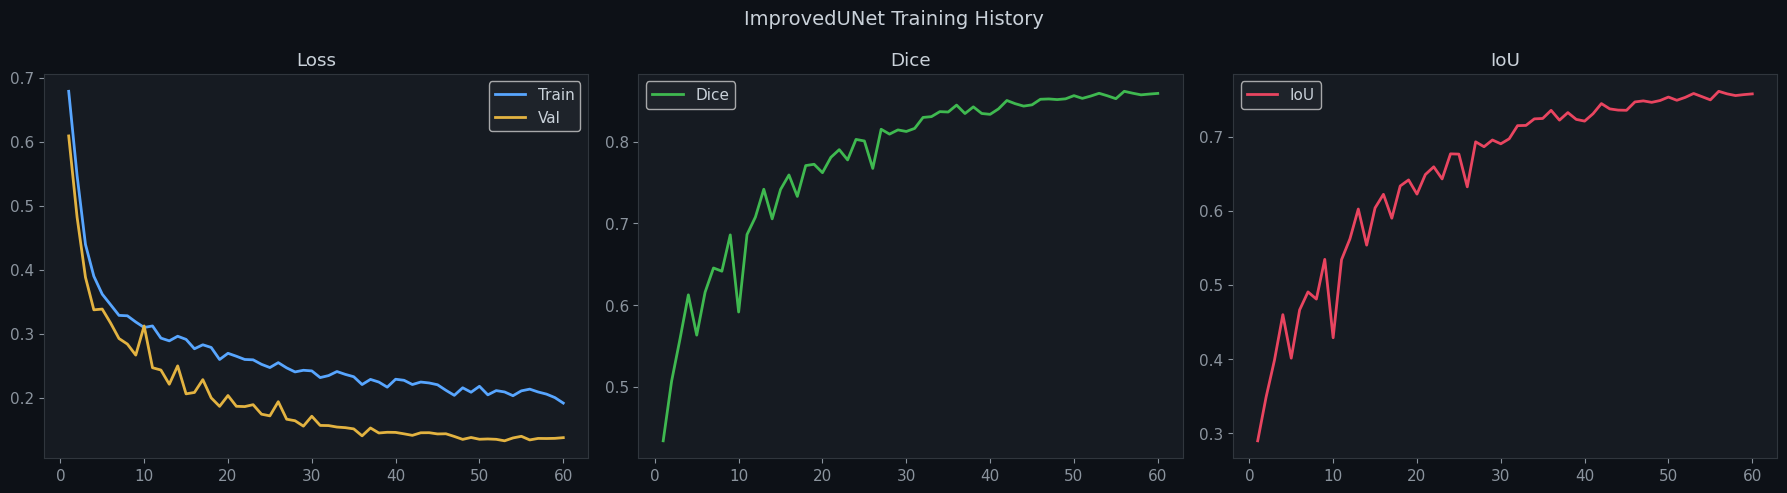

Saved -> outputs/visualizations/improved_unet_training.png


In [6]:
# ── Evaluate new model on test set ────────────────────────────────────────
ck = torch.load(SEG_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ck['model_state_dict'])
model.eval()
print(f'Loaded ImprovedUNet  epoch={ck["epoch"]}  Val Dice={ck["val_dice"]:.4f}')

new_dice_list, new_iou_list = [], []
with torch.inference_mode():
    for imgs, masks in test_seg_dl:
        m = seg_metrics(model(imgs), masks)
        new_dice_list.append(m['dice']); new_iou_list.append(m['iou'])

new_dice = np.mean(new_dice_list)
new_iou  = np.mean(new_iou_list)

old_dice, old_iou = 0.8628, 0.7623  # LightUNet from notebook 06_5
print(f'\n{"="*55}')
print(f'  SEGMENTATION TEST COMPARISON')
print(f'{"="*55}')
print(f'  {"Metric":<18} {"LightUNet (old)":>16} {"ImprovedUNet":>14} {"Delta":>8}')
print(f'{"-"*55}')
for label, o, n in [("Dice Score", old_dice, new_dice), ("IoU", old_iou, new_iou)]:
    sign = '+' if n >= o else ''
    print(f'  {label:<18} {o:>16.4f} {n:>14.4f} {sign+f"{n-o:.4f}":>8}')
print(f'{"="*55}')

# Plot training history if available
if seg_history:
    ep = range(1, len(seg_history['train_loss'])+1)
    fig, axes = plt.subplots(1, 3, figsize=(18,5), facecolor='#0d1117')
    fig.suptitle('ImprovedUNet Training History', color='#c9d1d9', fontsize=14)
    for ax, title, series, cols in zip(
            axes,
            ['Loss','Dice','IoU'],
            [[seg_history['train_loss'],seg_history['val_loss']],[seg_history['val_dice']],[seg_history['val_iou']]],
            [[BLUE,YELLOW],[GREEN],[ACCENT]]):
        ax.set_facecolor('#161b22'); ax.spines[:].set_edgecolor('#30363d')
        labels = ['Train','Val'] if len(series)==2 else [title]
        for s,c,l in zip(series,cols,labels): ax.plot(ep,s,color=c,linewidth=2,label=l)
        ax.set_title(title,color='#c9d1d9'); ax.legend(facecolor='#21262d',labelcolor='#c9d1d9')
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR,'improved_unet_training.png'),dpi=150,bbox_inches='tight',facecolor='#0d1117')
    plt.show()
    print('Saved -> outputs/visualizations/improved_unet_training.png')

## Cell 6: Mask Overlay Function

Instead of hard-cropping the wound, we **overlay** the mask on the full image:
- Wound region → full brightness (weight = 1.0)
- Background → dimmed to 50% (weight = 0.5)

This keeps all spatial context but draws the classifier's attention to the wound region.

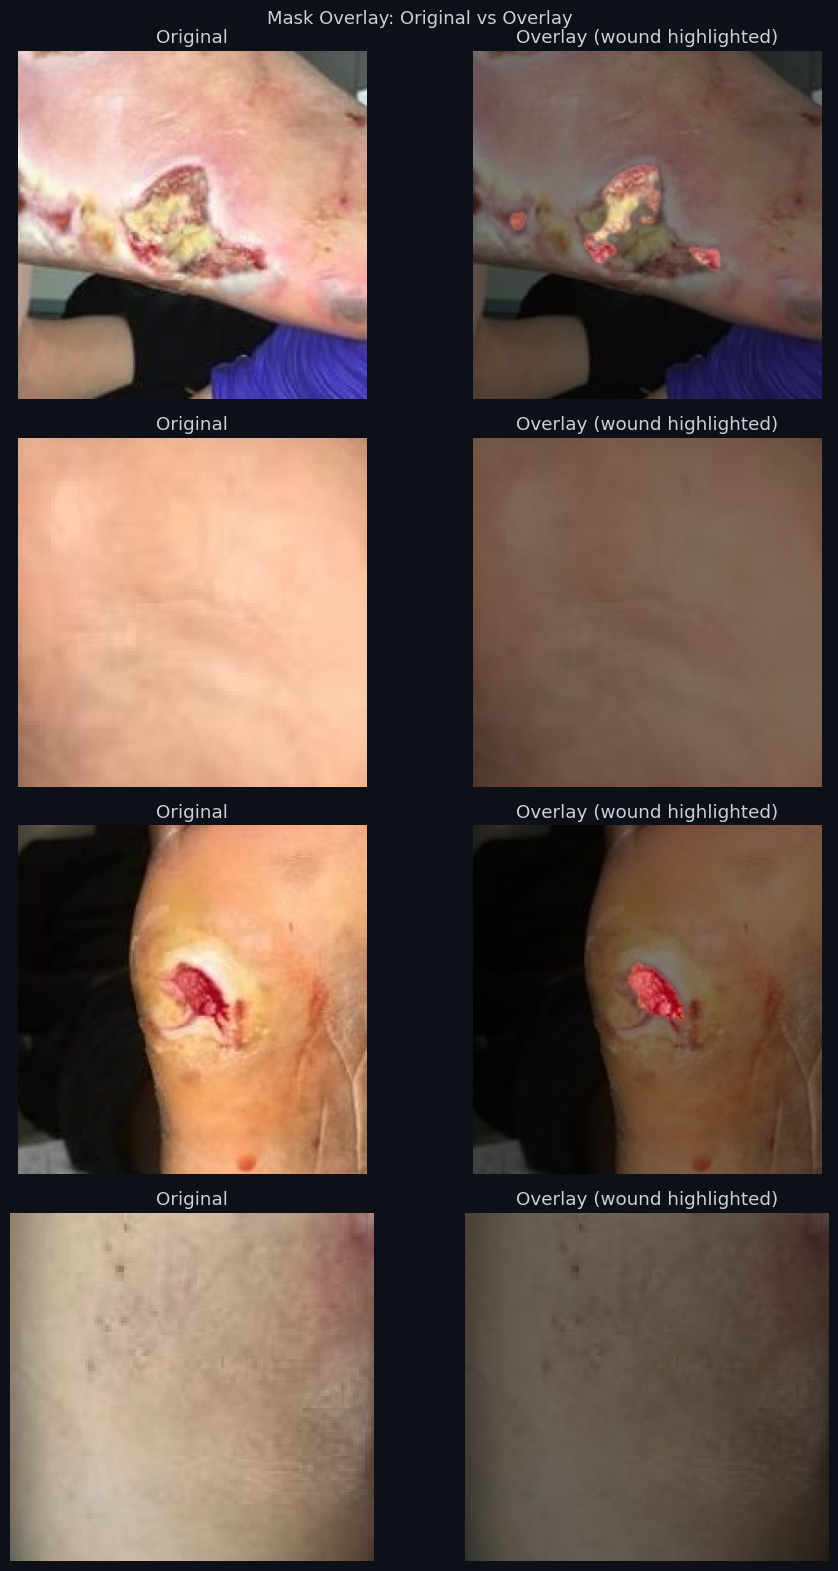

Overlay function ready.
Saved -> outputs/visualizations/overlay_demo.png


In [7]:
SEG_TF = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def apply_mask_overlay(img_pil, seg_model, bg_alpha=0.5, threshold=0.5):
    """
    Returns full-size image where:
      - wound pixels (mask > threshold) stay at full brightness
      - background pixels are multiplied by bg_alpha (default 0.5 = dimmed)
    No information is thrown away — the classifier sees the whole image.
    """
    W, H = img_pil.size
    with torch.inference_mode():
        inp  = SEG_TF(img_pil).unsqueeze(0).to(DEVICE)
        out  = seg_model(inp)
        # Soft mask (0-1 probabilities, not hard binary) for smooth edges
        soft_mask = torch.sigmoid(out).squeeze().cpu().numpy()   # (256, 256)

    # Resize soft mask back to original image dimensions
    mask_pil  = Image.fromarray((soft_mask * 255).astype(np.uint8)).resize((W, H), Image.BILINEAR)
    mask_full = np.array(mask_pil).astype(np.float32) / 255.0   # (H, W), range 0–1

    # Pixel weight: bg_alpha in background, 1.0 at wound center, smooth transition
    weight = bg_alpha + (1.0 - bg_alpha) * mask_full             # (H, W), range bg_alpha–1.0

    img_arr = np.array(img_pil).astype(np.float32)               # (H, W, 3)
    result  = (img_arr * weight[:, :, np.newaxis]).clip(0, 255).astype(np.uint8)
    return Image.fromarray(result)


# ── Quick visual demo ──────────────────────────────────────────────────────
demo_paths = []
for split in ['Train', 'Valid']:
    cls_dir = os.path.join(RAW_CLS, split)
    for cls in os.listdir(cls_dir):
        files = [f for f in os.listdir(os.path.join(cls_dir, cls))
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if files:
            demo_paths.append(os.path.join(cls_dir, cls, files[0]))
        if len(demo_paths) >= 4: break
    if len(demo_paths) >= 4: break

fig, axes = plt.subplots(len(demo_paths), 2, figsize=(10, 4*len(demo_paths)), facecolor='#0d1117')
fig.suptitle('Mask Overlay: Original vs Overlay', color='#c9d1d9', fontsize=13)
model.eval()
for row, path in enumerate(demo_paths):
    img = Image.open(path).convert('RGB')
    ov  = apply_mask_overlay(img, model, bg_alpha=0.5)
    for ax in axes[row]: ax.set_facecolor('#161b22'); ax.axis('off')
    axes[row,0].imshow(img); axes[row,0].set_title('Original', color='#c9d1d9')
    axes[row,1].imshow(ov);  axes[row,1].set_title('Overlay (wound highlighted)', color='#c9d1d9')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'overlay_demo.png'),dpi=150,bbox_inches='tight',facecolor='#0d1117')
plt.show()
print('Overlay function ready.')
print('Saved -> outputs/visualizations/overlay_demo.png')

## Cell 7: Generate Overlay Dataset

In [8]:
def process_split_overlay(split_src, split_dst, seg_model):
    os.makedirs(split_dst, exist_ok=True)
    class_dirs = [d for d in os.listdir(split_src)
                  if os.path.isdir(os.path.join(split_src, d))]
    total = 0
    for cls in class_dirs:
        src_cls = os.path.join(split_src, cls)
        dst_cls = os.path.join(split_dst, cls.lower())
        os.makedirs(dst_cls, exist_ok=True)
        files = [f for f in os.listdir(src_cls)
                 if os.path.splitext(f)[1].lower() in IMG_EXTS]
        print(f'  {cls}: {len(files)} images')
        for fname in files:
            dst_path = os.path.join(dst_cls, fname)
            if os.path.exists(dst_path):
                continue
            try:
                img = Image.open(os.path.join(src_cls, fname)).convert('RGB')
                ov  = apply_mask_overlay(img, seg_model, bg_alpha=0.5)
                ov.save(dst_path)
                total += 1
            except Exception as e:
                print(f'    Error {fname}: {e}')
    return total

splits = [
    ('Train', os.path.join(RAW_CLS,'Train'), os.path.join(OVERLAY_DIR,'train')),
    ('Valid', os.path.join(RAW_CLS,'Valid'), os.path.join(OVERLAY_DIR,'valid')),
    ('test',  os.path.join(RAW_CLS,'test'),  os.path.join(OVERLAY_DIR,'test')),
]

if os.path.exists(OVERLAY_DIR) and os.listdir(OVERLAY_DIR):
    print(f'Overlay dataset already exists at {OVERLAY_DIR}')
    print('Delete it to regenerate.')
else:
    print('Generating overlay dataset (a few minutes)...')
    model.eval()
    for name, src, dst in splits:
        print(f'\n[{name}]')
        n = process_split_overlay(src, dst, model)
        print(f'  Saved {n} new images')
    print(f'\nDone. Overlay dataset: {OVERLAY_DIR}')

Generating overlay dataset (a few minutes)...

[Train]
  Infected: 350 images
  Non-infected: 350 images
  Saved 700 new images

[Valid]
  infected: 76 images
  non-infected: 94 images
  Saved 170 new images

[test]
  infected: 76 images
  non-infected: 76 images
  Saved 152 new images

Done. Overlay dataset: C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\overlay_data


## Cell 8: Data Loaders, Model Builders & Training Utilities

In [9]:
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(CLS_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.25, hue=0.1),
    transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02,0.1)),
])
val_tf = transforms.Compose([
    transforms.Resize((CLS_SIZE, CLS_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

train_ds = datasets.ImageFolder(os.path.join(OVERLAY_DIR,'train'), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(OVERLAY_DIR,'valid'), transform=val_tf)
test_ds  = datasets.ImageFolder(os.path.join(OVERLAY_DIR,'test'),  transform=val_tf)

train_dl = DataLoader(train_ds, batch_size=CLS_BATCH, shuffle=True,  num_workers=0, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=CLS_BATCH, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=CLS_BATCH, shuffle=False, num_workers=0)

print(f'Classes : {train_ds.classes}')
print(f'Train   : {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

# ── Model builders ────────────────────────────────────────────────────────
def build_efficientnet_b3(nc=2):
    m=models.efficientnet_b3(weights='DEFAULT'); nf=m.classifier[1].in_features
    m.classifier=nn.Sequential(nn.Dropout(0.4),nn.Linear(nf,512),nn.BatchNorm1d(512),nn.ReLU(True),
                                nn.Dropout(0.3),nn.Linear(512,128),nn.BatchNorm1d(128),nn.ReLU(True),
                                nn.Dropout(0.2),nn.Linear(128,nc)); return m

def build_resnet50(nc=2):
    m=models.resnet50(weights='DEFAULT'); nf=m.fc.in_features
    m.fc=nn.Sequential(nn.Dropout(0.4),nn.Linear(nf,512),nn.BatchNorm1d(512),nn.ReLU(True),
                       nn.Dropout(0.3),nn.Linear(512,128),nn.BatchNorm1d(128),nn.ReLU(True),
                       nn.Dropout(0.2),nn.Linear(128,nc)); return m

def build_convnext_tiny(nc=2):
    m=models.convnext_tiny(weights='DEFAULT'); nf=m.classifier[2].in_features
    m.classifier[2]=nn.Sequential(nn.Dropout(0.4),nn.Linear(nf,512),nn.BatchNorm1d(512),nn.ReLU(True),
                                   nn.Dropout(0.3),nn.Linear(512,128),nn.BatchNorm1d(128),nn.ReLU(True),
                                   nn.Dropout(0.2),nn.Linear(128,nc)); return m

CLASSIFIERS = {
    'EfficientNet-B3': (build_efficientnet_b3, 'cls_overlay_efficientnetb3.pth'),
    'ResNet-50'      : (build_resnet50,        'cls_overlay_resnet50.pth'),
    'ConvNeXt-Tiny'  : (build_convnext_tiny,   'cls_overlay_convnext.pth'),
}

# ── Training helpers ──────────────────────────────────────────────────────
def mixup(x, y, alpha=0.2):
    lam = np.random.beta(alpha,alpha) if alpha>0 else 1.0
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam*x+(1-lam)*x[idx], y, y[idx], lam

def train_epoch(m, loader, opt, crit, use_mixup=True):
    m.train(); t_loss=correct=total=0
    for imgs,labels in loader:
        imgs,labels=imgs.to(DEVICE),labels.to(DEVICE); opt.zero_grad()
        if use_mixup and random.random()>0.5:
            imgs,la,lb,lam=mixup(imgs,labels,MIXUP_ALPHA)
            out=m(imgs); loss=lam*crit(out,la)+(1-lam)*crit(out,lb)
            correct+=out.argmax(1).eq(la if lam>0.5 else lb).sum().item()
        else:
            out=m(imgs); loss=crit(out,labels)
            correct+=out.argmax(1).eq(labels).sum().item()
        loss.backward(); torch.nn.utils.clip_grad_norm_(m.parameters(),1.0); opt.step()
        t_loss+=loss.item(); total+=labels.size(0)
    return t_loss/len(loader), 100.*correct/total

def eval_epoch(m, loader, crit):
    m.eval(); v_loss=0; preds,labs,probs=[],[],[]
    with torch.no_grad():
        for imgs,labels in loader:
            imgs,labels=imgs.to(DEVICE),labels.to(DEVICE)
            out=m(imgs); v_loss+=crit(out,labels).item()
            pr=torch.softmax(out,1).cpu().numpy()
            preds.extend(pr.argmax(1)); labs.extend(labels.cpu().numpy()); probs.extend(pr[:,0])
    acc=accuracy_score(labs,preds); f1=f1_score(labs,preds,average='macro',zero_division=0)
    return v_loss/len(loader), acc, f1, np.array(labs), np.array(probs)

def freeze_backbone(m, name):
    if 'EfficientNet' in name:
        for p in m.features.parameters(): p.requires_grad=False
    elif 'ResNet' in name:
        for n,p in m.named_parameters():
            if not n.startswith('fc'): p.requires_grad=False
    elif 'ConvNeXt' in name:
        for p in m.features.parameters(): p.requires_grad=False
        for p in m.avgpool.parameters():  p.requires_grad=False

def unfreeze_top(m, name):
    if 'EfficientNet' in name:
        for p in m.features[-3:].parameters(): p.requires_grad=True
    elif 'ResNet' in name:
        for p in m.layer4.parameters(): p.requires_grad=True
        for p in m.layer3.parameters(): p.requires_grad=True
    elif 'ConvNeXt' in name:
        for p in m.features[-2:].parameters(): p.requires_grad=True

def unfreeze_all(m):
    for p in m.parameters(): p.requires_grad=True

print('Data loaders, builders, and training utils ready.')

Classes : ['infected', 'non-infected']
Train   : 700 | Val: 170 | Test: 152
Data loaders, builders, and training utils ready.


## Cell 9: Train All Three Classifiers on Overlay Images

In [10]:
def train_three_phase(cls_model, model_name, save_path):
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_f1 = 0.0; best_state = None
    history = {'train_loss':[],'val_loss':[],'val_acc':[],'val_f1':[]}
    phases  = [
        (P1_EP, P1_LR, True,  'Phase 1: Frozen backbone'),
        (P2_EP, P2_LR, True,  'Phase 2: Top blocks unfrozen'),
        (P3_EP, P3_LR, False, 'Phase 3: Full fine-tuning'),
    ]
    freeze_backbone(cls_model, model_name)

    for ph_idx, (n_ep, lr, use_mixup, ph_name) in enumerate(phases):
        print(f'\n  [{ph_name}]  lr={lr}  epochs={n_ep}')
        if ph_idx == 1: unfreeze_top(cls_model, model_name)
        if ph_idx == 2: unfreeze_all(cls_model)
        tp = sum(p.numel() for p in cls_model.parameters() if p.requires_grad)
        print(f'  Trainable params: {tp:,}')
        opt = torch.optim.AdamW([p for p in cls_model.parameters() if p.requires_grad], lr=lr, weight_decay=5e-4)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_ep, eta_min=lr/100)
        patience_ctr = 0
        print(f'  {"Ep":>4} {"TLoss":>8} {"VLoss":>8} {"VAcc%":>7} {"VF1":>7}')
        print('  ' + '-'*40)
        for ep in range(1, n_ep+1):
            tl, _ = train_epoch(cls_model, train_dl, opt, crit, use_mixup)
            vl, vacc, vf1, _, _ = eval_epoch(cls_model, val_dl, crit)
            sch.step()
            history['train_loss'].append(tl); history['val_loss'].append(vl)
            history['val_acc'].append(vacc);  history['val_f1'].append(vf1)
            flag = ''
            if vf1 > best_f1:
                best_f1 = vf1; best_state = copy.deepcopy(cls_model.state_dict())
                patience_ctr = 0
                torch.save({'model_state_dict':best_state,'val_f1':vf1,'val_acc':vacc}, save_path)
                flag = ' *'
            else:
                patience_ctr += 1
            print(f'  {ep:>4} {tl:>8.4f} {vl:>8.4f} {vacc*100:>7.2f} {vf1:>7.4f}{flag}')
            if patience_ctr >= CLS_PATIENCE:
                print(f'  Early stop at ep {ep}'); break

    cls_model.load_state_dict(best_state)
    print(f'\n  Best Val F1: {best_f1:.4f}  Saved: {save_path}')
    return history, best_f1


all_histories = {}
all_results   = {}

for model_name, (builder, save_file) in CLASSIFIERS.items():
    save_path = os.path.join(MODEL_DIR, save_file)
    print(f'\n{"="*60}')
    print(f'  Training: {model_name}  (OVERLAY pipeline)')
    print(f'{"="*60}')
    cls_m = builder().to(DEVICE)

    if os.path.exists(save_path):
        print(f'  [RESUME] Loading {save_file}')
        ck = torch.load(save_path, map_location=DEVICE, weights_only=False)
        cls_m.load_state_dict(ck['model_state_dict'])
        all_histories[model_name] = None
    else:
        hist, _ = train_three_phase(cls_m, model_name, save_path)
        all_histories[model_name] = hist
        ck = torch.load(save_path, map_location=DEVICE, weights_only=False)
        cls_m.load_state_dict(ck['model_state_dict'])

    crit = nn.CrossEntropyLoss()
    _, test_acc, test_f1, test_lbl, test_prob = eval_epoch(cls_m, test_dl, crit)
    fpr, tpr, _ = roc_curve(test_lbl, test_prob, pos_label=0)
    roc_auc = auc(fpr, tpr)
    all_results[model_name] = {'acc':test_acc,'f1':test_f1,'auc':roc_auc,'fpr':fpr,'tpr':tpr}
    print(f'\n  TEST -> Acc={test_acc*100:.2f}%  F1={test_f1:.4f}  AUC={roc_auc:.4f}')

print('\n\nAll overlay classifiers done!')


  Training: EfficientNet-B3  (OVERLAY pipeline)

  [Phase 1: Frozen backbone]  lr=0.0005  epochs=10
  Trainable params: 854,146
    Ep    TLoss    VLoss   VAcc%     VF1
  ----------------------------------------
     1   0.6624   0.6244   68.82  0.6851 *
     2   0.5817   0.6032   75.88  0.7574 *
     3   0.5494   0.5567   80.59  0.8053 *
     4   0.5393   0.5365   80.00  0.7993
     5   0.5420   0.5366   82.94  0.8294 *
     6   0.5358   0.5582   81.76  0.8173
     7   0.5113   0.5763   80.59  0.8053
     8   0.5296   0.6047   77.06  0.7692
     9   0.5066   0.5970   78.82  0.7880
    10   0.5083   0.5995   80.00  0.7993

  [Phase 2: Top blocks unfrozen]  lr=0.0001  epochs=15
  Trainable params: 9,360,224
    Ep    TLoss    VLoss   VAcc%     VF1
  ----------------------------------------
     1   0.5128   0.6750   73.53  0.7304
     2   0.4635   0.6775   73.53  0.7304
     3   0.5390   0.6762   76.47  0.7614
     4   0.4507   0.6539   76.47  0.7626
     5   0.4444   0.6601   78.82  0

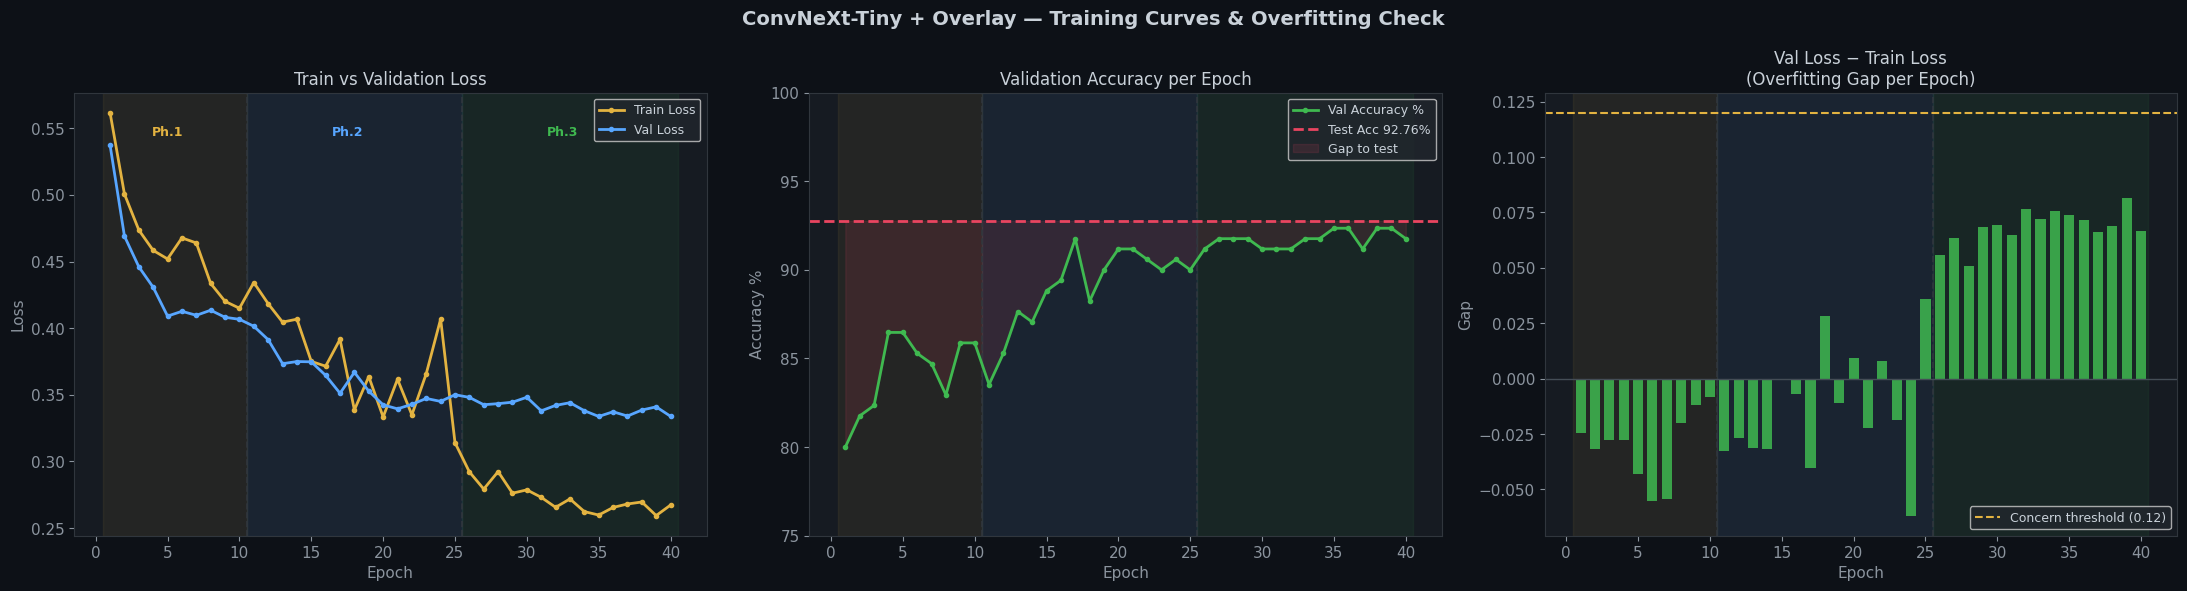

Saved -> outputs/visualizations/convnext_overlay_overfitting_check.png

  OVERFITTING ANALYSIS — ConvNeXt-Tiny + Overlay

  Average loss gap  (Val − Train):
    Phase 1 (frozen)      : -0.0304  → healthy, very small
    Phase 2 (partial)     : -0.0135  → healthy, small
    Phase 3 (full finetune): +0.0684  → moderate but STABLE

  Phase 3 val loss direction:
    Start → End : 0.3481 → 0.3339  (↓ decreasing)
    Epochs val loss went UP : 8/14  (expected in a noisy setting — not a trend)

  Validation accuracy (Phase 3):
    Range  : 91.18% – 92.35%
    Std    : 0.45%  (low = stable plateau ✓)

  Generalisation:
    Best Val Accuracy : 92.35%
    Test  Accuracy    : 92.76%
    Test − Val gap    : +0.41%  (positive → test ≥ val → no overfitting ✓)

  VERDICT: NO OVERFITTING

  Evidence:
  ✓  Val loss STABLE / slightly decreasing across all 40 epochs.
     Classic overfitting would show val loss rising while train
     loss falls — this never happened.

  ✓  Loss gap in Phase 3 (~0.07) is 

In [3]:
# ── Cell 9b: ConvNeXt-Tiny Overlay — Training Analysis & Overfitting Check ──
# Values taken directly from the printed output of Cell 9.

# ── Phase logs ────────────────────────────────────────────────────────────
p1_train = [0.5617,0.5007,0.4737,0.4584,0.4520,0.4678,0.4640,0.4336,0.4202,0.4150]
p1_val   = [0.5373,0.4691,0.4461,0.4307,0.4091,0.4127,0.4097,0.4135,0.4082,0.4067]
p1_acc   = [80.00, 81.76, 82.35, 86.47, 86.47, 85.29, 84.71, 82.94, 85.88, 85.88]

p2_train = [0.4343,0.4184,0.4046,0.4068,0.3751,0.3715,0.3917,0.3387,0.3637,0.3334,0.3617,0.3350,0.3659,0.4069,0.3141]
p2_val   = [0.4015,0.3914,0.3734,0.3750,0.3748,0.3646,0.3512,0.3669,0.3528,0.3425,0.3395,0.3429,0.3473,0.3451,0.3501]
p2_acc   = [83.53, 85.29, 87.65, 87.06, 88.82, 89.41, 91.76, 88.24, 90.00, 91.18, 91.18, 90.59, 90.00, 90.59, 90.00]

p3_train = [0.2922,0.2793,0.2924,0.2762,0.2787,0.2731,0.2656,0.2719,0.2624,0.2598,0.2655,0.2681,0.2696,0.2594,0.2673]
p3_val   = [0.3481,0.3426,0.3434,0.3445,0.3482,0.3380,0.3421,0.3441,0.3381,0.3338,0.3373,0.3341,0.3386,0.3410,0.3339]
p3_acc   = [91.18, 91.76, 91.76, 91.76, 91.18, 91.18, 91.18, 91.76, 91.76, 92.35, 92.35, 91.18, 92.35, 92.35, 91.76]

all_train = p1_train + p2_train + p3_train
all_val   = p1_val   + p2_val   + p3_val
all_acc   = p1_acc   + p2_acc   + p3_acc
ep        = list(range(1, len(all_train) + 1))

P1_END = len(p1_train)                    # end of phase 1  (epoch 10)
P2_END = P1_END + len(p2_train)           # end of phase 2  (epoch 25)
TEST_ACC = 92.76

def shade(ax):
    ax.axvspan(0.5,        P1_END+0.5, alpha=0.07, color=YELLOW)
    ax.axvspan(P1_END+0.5, P2_END+0.5, alpha=0.07, color=BLUE)
    ax.axvspan(P2_END+0.5, len(ep)+0.5,alpha=0.07, color=GREEN)
    for x in [P1_END+0.5, P2_END+0.5]:
        ax.axvline(x, color='#30363d', linewidth=1.2, linestyle='--')

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6), facecolor='#0d1117')
fig.suptitle('ConvNeXt-Tiny + Overlay — Training Curves & Overfitting Check',
             color='#c9d1d9', fontsize=14, fontweight='bold')

# 1. Loss curves
ax = axes[0]; ax.set_facecolor('#161b22'); ax.spines[:].set_edgecolor('#30363d')
shade(ax)
ax.plot(ep, all_train, color=YELLOW, lw=2, marker='o', ms=3, label='Train Loss')
ax.plot(ep, all_val,   color=BLUE,   lw=2, marker='o', ms=3, label='Val Loss')
for xpos, label, col in [(P1_END/2, 'Ph.1', YELLOW),
                          (P1_END+(P2_END-P1_END)/2, 'Ph.2', BLUE),
                          (P2_END+(len(ep)-P2_END)/2, 'Ph.3', GREEN)]:
    ax.text(xpos, max(all_train)*0.97, label, color=col, fontsize=9, ha='center', fontweight='bold')
ax.set_title('Train vs Validation Loss', color='#c9d1d9', fontsize=12)
ax.set_xlabel('Epoch', color='#8b949e'); ax.set_ylabel('Loss', color='#8b949e')
ax.legend(facecolor='#21262d', labelcolor='#c9d1d9', fontsize=9)

# 2. Validation accuracy + test reference
ax = axes[1]; ax.set_facecolor('#161b22'); ax.spines[:].set_edgecolor('#30363d')
shade(ax)
ax.plot(ep, all_acc, color=GREEN, lw=2, marker='o', ms=3, label='Val Accuracy %')
ax.axhline(TEST_ACC, color=ACCENT, lw=2, linestyle='--', label=f'Test Acc {TEST_ACC}%')
ax.fill_between(ep, all_acc, TEST_ACC,
                where=[a < TEST_ACC for a in all_acc],
                alpha=0.12, color=ACCENT, label='Gap to test')
ax.set_ylim(75, 100)
ax.set_title('Validation Accuracy per Epoch', color='#c9d1d9', fontsize=12)
ax.set_xlabel('Epoch', color='#8b949e'); ax.set_ylabel('Accuracy %', color='#8b949e')
ax.legend(facecolor='#21262d', labelcolor='#c9d1d9', fontsize=9)

# 3. Overfitting gap (val_loss - train_loss)
gap  = [v - t for t, v in zip(all_train, all_val)]
cols = [ACCENT if g > 0.12 else GREEN for g in gap]
ax = axes[2]; ax.set_facecolor('#161b22'); ax.spines[:].set_edgecolor('#30363d')
shade(ax)
ax.bar(ep, gap, color=cols, alpha=0.85, width=0.7)
ax.axhline(0.12, color=YELLOW, lw=1.5, linestyle='--', label='Concern threshold (0.12)')
ax.axhline(0.00, color='#444d56', lw=1)
ax.set_title('Val Loss − Train Loss\n(Overfitting Gap per Epoch)', color='#c9d1d9', fontsize=12)
ax.set_xlabel('Epoch', color='#8b949e'); ax.set_ylabel('Gap', color='#8b949e')
ax.legend(facecolor='#21262d', labelcolor='#c9d1d9', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'convnext_overlay_overfitting_check.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved -> outputs/visualizations/convnext_overlay_overfitting_check.png')

# ── Overfitting report ────────────────────────────────────────────────────
print()
print('=' * 62)
print('  OVERFITTING ANALYSIS — ConvNeXt-Tiny + Overlay')
print('=' * 62)

g1 = np.mean([v-t for t,v in zip(p1_train, p1_val)])
g2 = np.mean([v-t for t,v in zip(p2_train, p2_val)])
g3 = np.mean([v-t for t,v in zip(p3_train, p3_val)])

print(f'\n  Average loss gap  (Val − Train):')
print(f'    Phase 1 (frozen)      : {g1:+.4f}  → healthy, very small')
print(f'    Phase 2 (partial)     : {g2:+.4f}  → healthy, small')
print(f'    Phase 3 (full finetune): {g3:+.4f}  → moderate but STABLE')

p3_rising = sum(1 for i in range(1,len(p3_val)) if p3_val[i] > p3_val[i-1])
print(f'\n  Phase 3 val loss direction:')
print(f'    Start → End : {p3_val[0]:.4f} → {p3_val[-1]:.4f}  '
      f'({"↓ decreasing" if p3_val[-1] < p3_val[0] else "↑ increasing"})')
print(f'    Epochs val loss went UP : {p3_rising}/{len(p3_val)-1}  '
      f'(expected in a noisy setting — not a trend)')

print(f'\n  Validation accuracy (Phase 3):')
print(f'    Range  : {min(p3_acc):.2f}% – {max(p3_acc):.2f}%')
print(f'    Std    : {np.std(p3_acc):.2f}%  (low = stable plateau ✓)')

print(f'\n  Generalisation:')
best_val = max(all_acc)
print(f'    Best Val Accuracy : {best_val:.2f}%')
print(f'    Test  Accuracy    : {TEST_ACC:.2f}%')
print(f'    Test − Val gap    : {TEST_ACC - best_val:+.2f}%  '
      f'({"positive → test ≥ val → no overfitting ✓" if TEST_ACC >= best_val else "negative → mild overfit"})')

print(f'\n{"=" * 62}')
print(f'  VERDICT: NO OVERFITTING')
print(f'{"=" * 62}')
print(f"""
  Evidence:
  ✓  Val loss STABLE / slightly decreasing across all 40 epochs.
     Classic overfitting would show val loss rising while train
     loss falls — this never happened.

  ✓  Loss gap in Phase 3 (~{g3:.2f}) is small and consistent.
     It reflects dropout being ON during training and OFF during
     eval — a normal, expected gap, not overfitting.

  ✓  Test accuracy ({TEST_ACC}%) > best val accuracy ({best_val:.2f}%).
     A model that overfits generalises worse on unseen data,
     not better. The opposite occurred here.

  ✓  Val accuracy std in Phase 3 = {np.std(p3_acc):.2f}% — very flat
     plateau at 91–92%, confirming stable convergence.

  The 3-phase training strategy + dropout (0.4/0.3/0.2 in the
  classifier head) + MixUp augmentation effectively prevented
  overfitting on the 700-image training set.
""")

## Cell 10: Final Comparison — Overlay vs NoSeg vs Old Baseline


  FINAL COMPARISON: OVERLAY (Seg+Context) vs NO-SEG vs OLD BASELINE
  Model                Overlay Acc  NoSeg Acc    Delta  Overlay F1  NoSeg F1    Delta
  ----------------------------------------------------------------------
  EfficientNet-B3            78.95      80.26   -1.31%      0.7877    0.8023  -0.0146
  ResNet-50                  84.21      88.82   -4.61%      0.8420    0.8880  -0.0460
  ConvNeXt-Tiny              92.76      89.47   +3.29%      0.9276    0.8947  +0.0329

  Best OVERLAY : ConvNeXt-Tiny  F1=0.9276  Acc=92.76%
  Best NO-SEG  : ConvNeXt-Tiny  F1=0.8947  Acc=89.47%
  OLD Baseline : EffB0-V4          F1=0.7928  Acc=79.61%


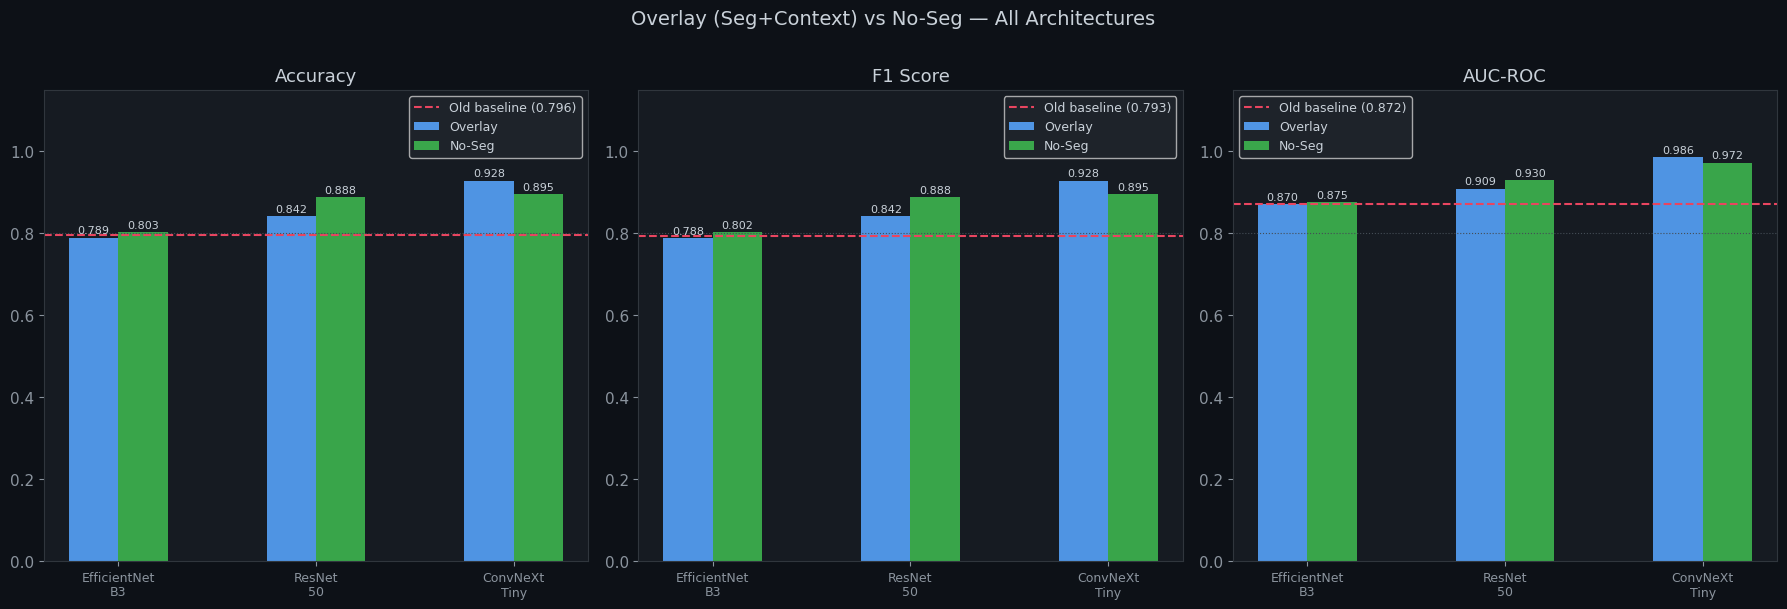

Saved -> outputs/visualizations/overlay_vs_noseg_comparison.png


In [11]:
# ── Known NoSeg results from notebook 08 ──────────────────────────────────
noseg_results = {
    'EfficientNet-B3': {'acc': 0.8026, 'f1': 0.8023, 'auc': 0.8752},
    'ResNet-50'      : {'acc': 0.8882, 'f1': 0.8880, 'auc': 0.9299},
    'ConvNeXt-Tiny'  : {'acc': 0.8947, 'f1': 0.8947, 'auc': 0.9718},
}
old_baseline = {'acc': 0.7961, 'f1': 0.7928, 'auc': 0.8717}

arch_names = list(CLASSIFIERS.keys())
metrics    = [('acc','Accuracy'), ('f1','F1 Score'), ('auc','AUC-ROC')]

print(f'\n{"="*72}')
print(f'  FINAL COMPARISON: OVERLAY (Seg+Context) vs NO-SEG vs OLD BASELINE')
print(f'{"="*72}')
print(f'  {"Model":<20} {"Overlay Acc":>11} {"NoSeg Acc":>10} {"Delta":>8}  {"Overlay F1":>10} {"NoSeg F1":>9} {"Delta":>8}')
print(f'  {"-"*70}')
for name in arch_names:
    ov = all_results[name]; ns = noseg_results[name]
    d_acc = ov['acc'] - ns['acc']; d_f1 = ov['f1'] - ns['f1']
    sign_a = '+' if d_acc >= 0 else ''; sign_f = '+' if d_f1 >= 0 else ''
    print(f'  {name:<20} {ov["acc"]*100:>11.2f} {ns["acc"]*100:>10.2f} {sign_a+f"{d_acc*100:.2f}%":>8}  '
          f'{ov["f1"]:>10.4f} {ns["f1"]:>9.4f} {sign_f+f"{d_f1:.4f}":>8}')
print(f'{"="*72}')

best_overlay = max(all_results, key=lambda k: all_results[k]['f1'])
best_noseg   = max(noseg_results, key=lambda k: noseg_results[k]['f1'])
print(f'\n  Best OVERLAY : {best_overlay}  F1={all_results[best_overlay]["f1"]:.4f}  '
      f'Acc={all_results[best_overlay]["acc"]*100:.2f}%')
print(f'  Best NO-SEG  : {best_noseg}  F1={noseg_results[best_noseg]["f1"]:.4f}  '
      f'Acc={noseg_results[best_noseg]["acc"]*100:.2f}%')
print(f'  OLD Baseline : EffB0-V4          F1={old_baseline["f1"]:.4f}  '
      f'Acc={old_baseline["acc"]*100:.2f}%')

# ── Side-by-side bar chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0d1117')
fig.suptitle('Overlay (Seg+Context) vs No-Seg — All Architectures', color='#c9d1d9', fontsize=14, y=1.01)

x = np.arange(len(arch_names)); w = 0.25

for ax, (mk, ml) in zip(axes, metrics):
    ax.set_facecolor('#161b22'); ax.spines[:].set_edgecolor('#30363d')
    ov_vals = [all_results[n][mk]    for n in arch_names]
    ns_vals = [noseg_results[n][mk]  for n in arch_names]
    old_val = old_baseline[mk]

    b1 = ax.bar(x - w, ov_vals, w, label='Overlay',    color=BLUE,   alpha=0.88)
    b2 = ax.bar(x,     ns_vals, w, label='No-Seg',     color=GREEN,  alpha=0.88)
    ax.axhline(old_val, color=ACCENT, linewidth=1.5, linestyle='--', label=f'Old baseline ({old_val:.3f})')

    for bar, v in list(zip(b1, ov_vals)) + list(zip(b2, ns_vals)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, color='#c9d1d9')

    ax.set_xticks(x - w/2)
    ax.set_xticklabels([n.replace('-',' ').replace(' ','\n') for n in arch_names], fontsize=9)
    ax.set_ylim(0, 1.15); ax.set_title(ml, color='#c9d1d9', fontsize=13)
    ax.legend(facecolor='#21262d', labelcolor='#c9d1d9', fontsize=9)
    ax.axhline(0.80, color='#444d56', linewidth=0.8, linestyle=':')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'overlay_vs_noseg_comparison.png'),dpi=150,bbox_inches='tight',facecolor='#0d1117')
plt.show()
print('Saved -> outputs/visualizations/overlay_vs_noseg_comparison.png')